In [1]:
import os
import pandas as pd
from typing import Dict, List, Optional, Tuple, Any
import kagglehub
import lmdb
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from transformers import pipeline
from dataclasses import dataclass
from copy import deepcopy
import time
import json
from pathlib import Path
import uuid
import concurrent.futures
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import hashlib
import pickle
import shutil
import yaml

/home/student/projects/FrameReaderTrain/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
path = kagglehub.dataset_download(
    "hardtype/rustitw-russian-language-visual-text-recognition"
)

Download already complete (135305919719 bytes).
Extracting files...


In [5]:
path

'/home/student/.cache/kagglehub/datasets/hardtype/rustitw-russian-language-visual-text-recognition/versions/2'

In [6]:
path_to_dataset = deepcopy(path)

In [7]:
# classificator = pipeline("text-classification", model="ERCDiDip/langdetect")
# classificator("")

In [16]:
@dataclass
class DataFormer:
    path_to_kaggle_dataset: str
    num_workers: int = 8
    lang_batch_size: int = 256
        
    def __post_init__(self) -> None:
        self.path_to_train_real = os.path.join(self.path_to_kaggle_dataset, 'train/real')
        self.path_to_train_synth = os.path.join(self.path_to_kaggle_dataset, 'train/synth')
        self.path_to_test_real = os.path.join(self.path_to_kaggle_dataset, 'test/real')
        self.path_to_test_synth = os.path.join(self.path_to_kaggle_dataset, 'test/synth')
        self.train_real_csv = pd.read_csv(os.path.join(self.path_to_train_real, 'info.csv'))
        self.train_synth_csv = pd.read_csv(os.path.join(self.path_to_train_synth, 'info.csv'))
        self.test_real_csv = pd.read_csv(os.path.join(self.path_to_test_real, 'info.csv'))
        self.test_synth_csv = pd.read_csv(os.path.join(self.path_to_test_synth, 'info.csv'))
        self.classificator = pipeline("text-classification", model="ERCDiDip/langdetect")

    @staticmethod
    def show_image(path_to_image: str, raw: pd.Series) -> None:

        im = cv2.imread(path_to_image)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots()
        ax.imshow(im)
        
        try:
            bboxes = json.loads(raw['box_and_label'])[0]
            for bbox in bboxes:
                x = bbox['left']    * raw['width']
                y = bbox['top']     * raw['height']
                w = bbox['width']   * raw['width']
                h = bbox['height']  * raw['height']
                rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='y', facecolor='none')
                ax.add_patch(rect)
            plt.title('\n'.join([bbox['label'] for bbox in bboxes]))
        except (json.JSONDecodeError, KeyError, IndexError) as e:
            plt.title(f"Error displaying bounding boxes: {str(e)}")
            
        plt.show()

    @staticmethod
    def crop_image(path_to_image: str, raw: pd.Series, show_img: bool = False) -> Optional[List[Tuple[Any, str]]]:
        im = cv2.imread(path_to_image)
        if im is None:
            print(f"Warning: Could not read image at {path_to_image}")
            return None
            
        results = []
        
        try:
            bboxes = json.loads(raw['box_and_label'])[0]
        except (json.JSONDecodeError, KeyError, IndexError) as e:
            print(f"Error processing bounding boxes: {str(e)}")
            return None
            
        for bbox in bboxes:
            label = bbox.get('label', '')
            x = int(bbox['left'] * raw['width'])
            y = int(bbox['top'] * raw['height'])
            w = int(bbox['width'] * raw['width'])
            h = int(bbox['height'] * raw['height'])
            
            if w <= 0 or h <= 0:
                continue

            x = max(0, x)
            y = max(0, y)
            w = min(w, im.shape[1] - x)
            h = min(h, im.shape[0] - y)
            
            if w <= 0 or h <= 0:
                continue

            cropped = cv2.resize(im[y:y+h, x:x+w], (256, 256))

            if show_img:
                plt_img = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
                fig, ax = plt.subplots()
                ax.imshow(plt_img)
                plt.title(label)
                plt.show()
            
            if cropped.size > 0:
                results.append((cropped, label.replace('\n', ' ')))

        return results
        
    def _split_data(self, df: pd.DataFrame, test_size: float = 0.2) -> tuple[pd.DataFrame, pd.DataFrame]:
        df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
        split_idx = int(len(df_shuffled) * (1 - test_size))
        return df_shuffled.iloc[:split_idx], df_shuffled.iloc[split_idx:]

    def _filter_russian_texts(self, df: pd.DataFrame) -> pd.DataFrame:
        """Фильтрация строк с русским текстом с батчингом и кэшированием"""
        if len(df) == 0:
            return df
        
        # Создаем надежную систему кэширования
        cache_dir = os.path.abspath(os.path.join(os.getcwd(), 'data_cache'))
        os.makedirs(cache_dir, exist_ok=True)
        
        # Генерируем уникальный хеш для DataFrame
        cache_hash = hashlib.md5(pd.util.hash_pandas_object(df).values.tobytes()).hexdigest()
        cache_filename = f"lang_filter_{cache_hash}.pkl"
        cache_path = os.path.join(cache_dir, cache_filename)
        
        # Проверяем кэш (только если это файл)
        if os.path.exists(cache_path):
            if os.path.isfile(cache_path):
                try:
                    with open(cache_path, 'rb') as f:
                        print(f"Loading from cache: {cache_filename}")
                        return pickle.load(f)
                except Exception as e:
                    print(f"Cache load error, regenerating: {str(e)}")
                    os.remove(cache_path)
            else:
                print(f"Cache path is directory, removing: {cache_path}")
                os.rmdir(cache_path)  # Удаляем мешающую директорию
        
        # Основная логика фильтрации
        texts = df['text'].astype(str).apply(lambda x: x.replace('\n', ' ')[:500]).tolist()
        batches = [texts[i:i + self.lang_batch_size] for i in range(0, len(texts), self.lang_batch_size)]
        
        russian_mask = np.zeros(len(texts), dtype=bool)
        with tqdm(total=len(batches), desc="Filtering Russian texts") as pbar:
            for batch_idx, batch in enumerate(batches):
                try:
                    results = self.classificator(batch)
                    batch_mask = [res['label'] == 'ru' for res in results]
                    start_idx = batch_idx * self.lang_batch_size
                    end_idx = start_idx + len(batch)
                    russian_mask[start_idx:end_idx] = batch_mask
                except Exception as e:
                    print(f"Batch {batch_idx} error: {str(e)}")
                pbar.update(1)
        
        # Сохранение результатов
        filtered_df = df[russian_mask].copy()
        try:
            with open(cache_path, 'wb') as f:
                pickle.dump(filtered_df, f)
            print(f"Results cached to: {cache_path}")
        except Exception as e:
            print(f"Failed to save cache: {str(e)}")
        
        return filtered_df

    def _process_row(self, raw, base_path, output_path, metadata_file):
        """Обработка одной строки данных"""
        # Проверка существующих файлов
        base_filename = Path(raw['image_path']).stem
        existing_files = set()
        
        # Генерация хеша для уникальности имени
        path_hash = hashlib.md5(raw['image_path'].encode()).hexdigest()[:6]
        
        # Проверка наличия текста и языка
        if 'text' in raw and len(raw['text']) > 0:
            try:
                text = raw['text'].replace('\n', ' ')[:500]
                lang = self.classificator(text)
                if lang[0]['label'] != 'ru':
                    return
            except Exception as e:
                print(f"Language error: {str(e)}")
                return

        # Проверка существования изображения
        img_path = os.path.join(base_path, raw['image_path'])
        if not os.path.exists(img_path):
            print(f"Missing image: {img_path}")
            return

        # Обработка кропов
        crops = self.crop_image(img_path, raw)
        if not crops:
            return

        # Сохранение кропов
        for i, (img, label) in enumerate(crops):
            if not label:
                continue

            # Генерация фиксированного имени
            unique_name = f"{base_filename}_{path_hash}_{i}.png"
            output_path_img = os.path.join(output_path, unique_name)
            
            # Проверка существования файла
            if os.path.exists(output_path_img):
                continue

            # Сохранение изображения и метаданных
            cv2.imwrite(output_path_img, img)
            metadata_entry = {
                "file_name": unique_name,
                "ground_truth": json.dumps({"gt_parse": label})
            }
            metadata_file.write(json.dumps(metadata_entry) + '\n')

    def _process_split(self, csv_data: pd.DataFrame, base_path: str, 
                      output_path: str, desc: str) -> None:
        """Обработка части данных с проверкой существующих файлов"""
        metadata_path = os.path.join(output_path, 'metadata.jsonl')
        os.makedirs(output_path, exist_ok=True)

        with open(metadata_path, 'a') as mfile, ThreadPoolExecutor(self.num_workers) as executor:
            futures = []
            for _, row in csv_data.iterrows():
                try:
                    base_filename = Path(row['image_path']).stem
                    path_hash = hashlib.md5(row['image_path'].encode()).hexdigest()[:6]
                    bboxes = json.loads(row['box_and_label'])[0]
                    expected_files = [
                        f"{base_filename}_{path_hash}_{i}.png" 
                        for i in range(len(bboxes))
                    ]
                    
                    # Проверяем существование всех ожидаемых файлов
                    if all(os.path.exists(os.path.join(output_path, f)) for f in expected_files):
                        continue
                        
                except (json.JSONDecodeError, KeyError, IndexError) as e:
                    print(f"Error parsing box_and_label: {str(e)}")
                    continue
                
                # Запуск задачи в потоке
                futures.append(
                    executor.submit(
                        self._process_row,
                        row.copy(),
                        base_path,
                        output_path,
                        mfile
                    )
                )

            # Прогресс-бар
            with tqdm(total=len(futures), desc=desc) as pbar:
                for future in concurrent.futures.as_completed(futures):
                    pbar.update(1)
                    try:
                        future.result()
                    except Exception as e:
                        print(f"Processing error: {str(e)}")

    def _save_yolo_config(self, output_path: str) -> None:
        """Сохранение конфигурационного файла data.yaml с фиксированным классом"""
        config = {
            'path': output_path,
            'train': 'train/images',
            'val': 'val/images',
            'test': 'test/images',
            'names': {0: 'text'}  # Фиксированный класс
        }
    
        with open(os.path.join(output_path, 'data.yaml'), 'w') as f:
            yaml.dump(config, f, default_flow_style=False)

    def _process_yolo_split(self, df: pd.DataFrame, base_paths: list, 
                       output_path: str, desc: str) -> None:
        """Обработка части данных для YOLO"""
        images_dir = os.path.join(output_path, 'images')
        labels_dir = os.path.join(output_path, 'labels')
        
        with ThreadPoolExecutor(self.num_workers) as executor:
            futures = []
            for _, row in df.iterrows():
                # Определяем базовый путь к изображению
                base_path = next(
                    (bp for bp in base_paths 
                     if os.path.exists(os.path.join(bp, row['image_path']))),
                    None
                )
                if not base_path:
                    continue
                
                futures.append(
                    executor.submit(
                        self._process_yolo_row,
                        row=row.copy(),
                        base_path=base_path,
                        images_dir=images_dir,
                        labels_dir=labels_dir
                    )
                )
            
            with tqdm(total=len(futures), desc=desc) as pbar:
                for future in concurrent.futures.as_completed(futures):
                    pbar.update(1)
                    try:
                        future.result()
                    except Exception as e:
                        print(f"Error: {str(e)}")

    def _process_yolo_row(self, row, base_path: str, 
                     images_dir: str, labels_dir: str) -> None:
        """Обработка одной строки для YOLO с классом 0 и нормализованными координатами"""
        img_path = os.path.join(base_path, row['image_path'])
        if not os.path.exists(img_path):
            return
        
        # Чтение изображения для получения размеров
        img = cv2.imread(img_path)
        if img is None:
            return
            
        img_height, img_width = img.shape[:2]
        
        # Генерация путей
        base_name = Path(row['image_path']).stem
        image_filename = f"{base_name}.jpg"
        label_filename = f"{base_name}.txt"
        
        # Пропускаем уже обработанные файлы
        if os.path.exists(os.path.join(images_dir, image_filename)):
            return
            
        # Сохранение изображения
        cv2.imwrite(os.path.join(images_dir, image_filename), img)
        
        # Обработка аннотаций с нормализацией координат
        label_lines = []
        try:
            bboxes = json.loads(row['box_and_label'])[0]
            for bbox in bboxes:
                # Пропускаем пустые боксы
                if not bbox.get('label', '').strip():
                    continue
                
                # Нормализация координат в формат YOLO:
                # x_center, y_center, width, height (все значения от 0 до 1)
                x_center = (bbox['left'] + bbox['width'] / 2) 
                y_center = (bbox['top'] + bbox['height'] / 2)
                width = bbox['width']
                height = bbox['height']
                
                # Проверка корректности координат
                if (x_center < 0 or x_center > 1 or 
                    y_center < 0 or y_center > 1 or
                    width <= 0 or width > 1 or
                    height <= 0 or height > 1):
                    print(f"Invalid bbox coordinates: {bbox}")
                    continue
                
                label_lines.append(
                    f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
                )
        except Exception as e:
            print(f"Annotation error: {str(e)}")
            return
            
        # Сохранение аннотаций
        if label_lines:
            with open(os.path.join(labels_dir, label_filename), 'w') as f:
                f.write('\n'.join(label_lines))

    def form_yolo_format(self, path_to_yolo_output: str, process_limit: int = None) -> None:
        """Создание YOLO формата данных с фиксированным классом 1"""
        path_to_yolo = os.path.join(path_to_yolo_output, 'yolo')
        
        # Создаем структуру директорий
        splits = ['train', 'val', 'test']
        for split in splits:
            for subdir in ['images', 'labels']:
                os.makedirs(os.path.join(path_to_yolo, split, subdir), exist_ok=True)
        
        # Сохраняем конфигурационный файл
        self._save_yolo_config(path_to_yolo)
        
        # Используем уже отфильтрованные данные из кэша
        filtered_data = {
            'train_real': self._filter_russian_texts(self.train_real_csv.head(process_limit)),
            'train_synth': self._filter_russian_texts(self.train_synth_csv.head(process_limit)),
            'test_real': self._filter_russian_texts(self.test_real_csv.head(process_limit)),
            'test_synth': self._filter_russian_texts(self.test_synth_csv.head(process_limit))
        }
        
        # Обработка train данных
        train_real_split = self._split_data(filtered_data['train_real'])
        train_synth_split = self._split_data(filtered_data['train_synth'])
        
        # Объединяем реальные и синтетические данные
        train_data = pd.concat([train_real_split[0], train_synth_split[0]])
        val_data = pd.concat([train_real_split[1], train_synth_split[1]])
        
        # Сохраняем train/val
        self._process_yolo_split(
            df=train_data,
            base_paths=[self.path_to_train_real, self.path_to_train_synth],
            output_path=os.path.join(path_to_yolo, 'train'),
            desc='Processing YOLO train data'
        )
        
        self._process_yolo_split(
            df=val_data,
            base_paths=[self.path_to_train_real, self.path_to_train_synth],
            output_path=os.path.join(path_to_yolo, 'val'),
            desc='Processing YOLO validation data'
        )
        
        # Обработка test данных
        self._process_yolo_split(
            df=filtered_data['test_real'],
            base_paths=[self.path_to_test_real],
            output_path=os.path.join(path_to_yolo, 'test'),
            desc='Processing YOLO test real data'
        )
        
        self._process_yolo_split(
            df=filtered_data['test_synth'],
            base_paths=[self.path_to_test_synth],
            output_path=os.path.join(path_to_yolo, 'test'),
            desc='Processing YOLO test synth data'
        )

    def form_donut_format(self, path_to_donut_output: str, process_limit: int = None) -> None:
        """Основной метод обработки данных"""
        path_to_donut = os.path.join(path_to_donut_output, 'donut')
        os.makedirs(path_to_donut, exist_ok=True)
        
        # Фильтрация данных перед обработкой
        filtered_data = {
            'train_real': self._filter_russian_texts(self.train_real_csv.head(process_limit)),
            'train_synth': self._filter_russian_texts(self.train_synth_csv.head(process_limit)),
            'test_real': self._filter_russian_texts(self.test_real_csv.head(process_limit)),
            'test_synth': self._filter_russian_texts(self.test_synth_csv.head(process_limit))
        }
        
        # Обработка train real данных
        if len(filtered_data['train_real']) > 0:
            train_real_train, train_real_val = self._split_data(filtered_data['train_real'])
            self._process_split(
                csv_data=train_real_train,
                base_path=self.path_to_train_real,
                output_path=os.path.join(path_to_donut, 'train'),
                desc='Processing train real data (train split)'
            )
            self._process_split(
                csv_data=train_real_val,
                base_path=self.path_to_train_real,
                output_path=os.path.join(path_to_donut, 'valid'),
                desc='Processing train real data (validation split)'
            )
        
        # Обработка train synth данных
        if len(filtered_data['train_synth']) > 0:
            train_synth_train, train_synth_val = self._split_data(filtered_data['train_synth'])
            self._process_split(
                csv_data=train_synth_train,
                base_path=self.path_to_train_synth,
                output_path=os.path.join(path_to_donut, 'train'),
                desc='Processing train synthetic data (train split)'
            )
            self._process_split(
                csv_data=train_synth_val,
                base_path=self.path_to_train_synth,
                output_path=os.path.join(path_to_donut, 'valid'),
                desc='Processing train synthetic data (validation split)'
            )
        
        # Обработка test данных
        if len(filtered_data['test_real']) > 0:
            self._process_split(
                csv_data=filtered_data['test_real'],
                base_path=self.path_to_test_real,
                output_path=os.path.join(path_to_donut, 'test'),
                desc='Processing test real data'
            )
        
        if len(filtered_data['test_synth']) > 0:
            self._process_split(
                csv_data=filtered_data['test_synth'],
                base_path=self.path_to_test_synth,
                output_path=os.path.join(path_to_donut, 'test'),
                desc='Processing test synthetic data'
            )

In [17]:
former = DataFormer(path_to_dataset)

Device set to use cuda:0


In [ ]:
former.form_donut_format(os.path.join('/home/student/projects/FrameReaderTrain/dataset/ocr'))

Loading from cache: lang_filter_bb1555093c5749c1a0b8b3a3c06db519.pkl
Loading from cache: lang_filter_9ba28e333454a1ea1cd87887e53fe8a2.pkl
Loading from cache: lang_filter_edcfba1c1af9701b195e81d33dc62a5b.pkl
Loading from cache: lang_filter_bd4b0127403e7b9b753b34a2353ecfcf.pkl


Processing train synthetic data (train split): 100%|███████████████████████████| 529368/529368 [1:31:54<00:00, 95.99it/s]
Processing train synthetic data (validation split):  51%|████████████▋            | 67222/132343 [11:25<12:14, 88.71it/s]libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (validation split):  51%|████████████▋            | 67231/132343 [11:25<12:57, 83.72it/s]libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (valid

Processing error: [Errno 28] No space left on device


libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (validation split):  51%|████████████▋            | 67271/132343 [11:25<12:00, 90.34it/s]libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (validation split):  51%|████████████▋            | 67281/132343 [1

Processing error: [Errno 28] No space left on device


...

libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (validation split):  68%|█████████████████        | 90314/132343 [15:34<08:24, 83.33it/s]libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write E

Processing error: [Errno 28] No space left on device


Processing train synthetic data (validation split):  68%|█████████████████        | 90336/132343 [15:35<07:38, 91.63it/s]libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (validation split):  68%|█████████████████        | 90346/132343 [15:35<08:02, 87.04it/s]libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
Processing train synthetic data (validation split):  68%|█████████████████        | 90355/132343 [15:35<08:09, 85.86it/s]

Processing error: [Errno 28] No space left on device


Processing train synthetic data (validation split):  75%|██████████████████▋      | 99124/132343 [17:13<06:25, 86.23it/s]

In [11]:
former.form_yolo_format(os.path.join('/home/student/projects/FrameReaderTrain/dataset/detection'))

Loading from cache: lang_filter_bb1555093c5749c1a0b8b3a3c06db519.pkl
Loading from cache: lang_filter_9ba28e333454a1ea1cd87887e53fe8a2.pkl
Loading from cache: lang_filter_edcfba1c1af9701b195e81d33dc62a5b.pkl
Loading from cache: lang_filter_bd4b0127403e7b9b753b34a2353ecfcf.pkl
Invalid bbox coordinates: {'left': 0, 'top': 0, 'width': 679.5980392156864, 'height': 275.468137254902, 'label': 'а\nмороженое\nиги кофе\n_ПО', 'shape': 'rectangle'}
Invalid bbox coordinates: {'left': 0, 'top': 0, 'width': 18937.5, 'height': 6750, 'label': 'frs-ag.com', 'shape': 'rectangle'}
Invalid bbox coordinates: {'left': 0, 'top': 0, 'width': 422, 'height': 62, 'label': 'Ялта ... Мебель и интерьер Шкафы, комоды и стеллажи Шкафы\nБуфет старинный антикварный', 'shape': 'rectangle'}
Invalid bbox coordinates: {'left': 495, 'top': 0, 'width': 158, 'height': 86, 'label': '15 330 000 р', 'shape': 'rectangle'}
Invalid bbox coordinates: {'left': 1, 'top': 67, 'width': 415, 'height': 41, 'label': 'Добавить в избранное Д

Processing YOLO train data:   7%|█████▋                                                                              | 37037/543159 [00:57<24:36, 342.69it/s]

Invalid bbox coordinates: {'left': 0.06579291075468063, 'top': 0.8205468851795952, 'width': 0.3045259788632393, 'height': 0.45328702522367964, 'label': 'психануть', 'shape': 'rectangle'}


Processing YOLO train data:   9%|███████▋                                                                            | 50079/543159 [01:46<28:55, 284.19it/s]

Invalid bbox coordinates: {'left': 0.3683594763278961, 'top': 0.8668840680803571, 'width': 0.3489658534526825, 'height': 0.2697825449290293, 'label': 'кремировать', 'shape': 'rectangle'}


...

Processing YOLO test synth data:  70%|███████████████████████████████████████████████████████▊                        | 26423/37916 [01:35<00:42, 267.84it/s]

Invalid bbox coordinates: {'left': 0.20744498570760092, 'top': 0.007463311776518822, 'width': 0.1314039627710978, 'height': 2.2540732864290476, 'label': 'тоненько', 'shape': 'rectangle'}


Processing YOLO test synth data:  76%|████████████████████████████████████████████████████████████▋                   | 28761/37916 [01:44<00:34, 266.98it/s]

Invalid bbox coordinates: {'left': 0.2621496915817261, 'top': 0.06905182502800869, 'width': 1.0068117380142212, 'height': 0.3298913280234418, 'label': 'Слабко', 'shape': 'rectangle'}


Processing YOLO test synth data: 100%|████████████████████████████████████████████████████████████████████████████████| 37916/37916 [02:18<00:00, 274.14it/s]


In [12]:
def visualize_yolo_detection(image_path: str, label_path: str, class_names: dict = {0: 'text'}):
    """
    Визуализирует изображение с bounding boxes и текстом в формате YOLO
    
    Args:
        image_path (str): Путь к изображению
        label_path (str): Путь к файлу с аннотациями YOLO
        class_names (dict): Словарь соответствия классов {class_id: class_name}
    """
    # Читаем изображение
    img = cv2.imread(image_path)
    if img is None:
        print(f"Ошибка: не удалось загрузить изображение {image_path}")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width = img.shape[:2]
    
    # Читаем аннотации
    try:
        with open(label_path, 'r') as f:
            annotations = f.readlines()
    except FileNotFoundError:
        print(f"Ошибка: файл аннотаций {label_path} не найден")
        return
    
    # Создаем фигуру
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    ax = plt.gca()
    
    # Обрабатываем каждую аннотацию
    for ann in annotations:
        parts = ann.strip().split()
        if len(parts) != 5:
            continue
            
        class_id, x_center, y_center, width, height = map(float, parts)
        class_id = int(class_id)
        
        # Конвертируем нормализованные координаты в пиксельные
        x_center *= img_width
        y_center *= img_height
        width *= img_width
        height *= img_height
        
        # Вычисляем координаты прямоугольника
        x_min = x_center - width / 2
        y_min = y_center - height / 2
        
        # Рисуем bounding box
        rect = plt.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Добавляем текст
        class_name = class_names.get(class_id, str(class_id))
        plt.text(
            x_min, y_min - 5, class_name,
            color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
    
    plt.title(f"Image: {Path(image_path).name}\nAnnotations: {Path(label_path).name}")
    plt.axis('off')
    plt.show()

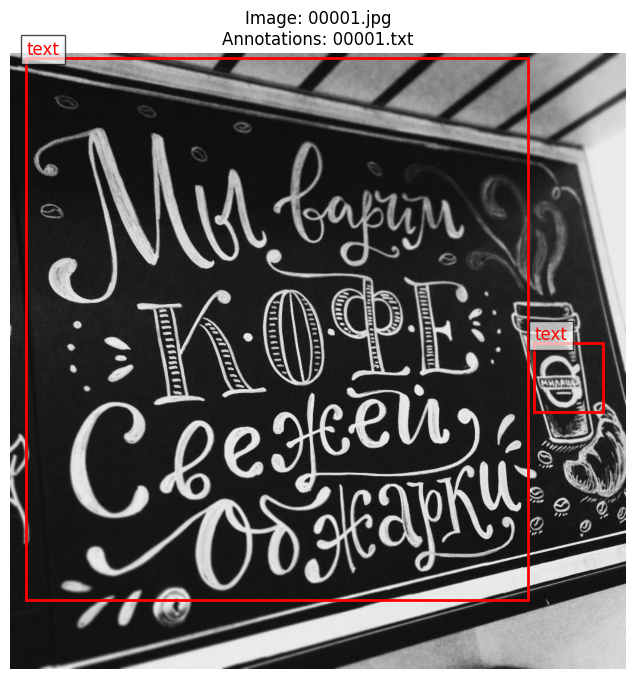

In [13]:
# Пути к файлам
image_path = "/home/student/projects/FrameReaderTrain/dataset/detection/yolo/train/images/00001.jpg"
label_path = "/home/student/projects/FrameReaderTrain/dataset/detection/yolo/train/labels/00001.txt"

# Визуализация
visualize_yolo_detection(image_path, label_path)

In [4]:
def restructure_donut_dataset(
    donut_path: str, 
    backup_path: Optional[str] = None,
    move_files: bool = True
) -> None:
    """
    Restructures the donut dataset by separating real and synthetic images.
    
    Args:
        donut_path: Path to the donut dataset directory
        backup_path: Path to save backup of original metadata.jsonl files
        move_files: If True, moves files instead of copying them
    
    The function:
    1. Creates real/synth subdirectories with train/test/valid structure
    2. Separates files based on filename pattern (lhr_* = synthetic)
    3. Updates metadata.jsonl files accordingly
    4. Optionally backs up original metadata files
    """
    # Define paths
    splits = ["train", "test", "valid"]
    real_dir = os.path.join(donut_path, "real")
    synth_dir = os.path.join(donut_path, "synth")
    
    # Create new directory structure
    for target_dir in [real_dir, synth_dir]:
        for split in splits:
            os.makedirs(os.path.join(target_dir, split), exist_ok=True)
    
    # Backup original metadata if requested
    if backup_path:
        os.makedirs(backup_path, exist_ok=True)
        for split in splits:
            original_metadata = os.path.join(donut_path, split, "metadata.jsonl")
            if os.path.exists(original_metadata):
                backup_file = os.path.join(backup_path, f"{split}_metadata.jsonl")
                shutil.copy2(original_metadata, backup_file)
                print(f"Backed up {split} metadata to {backup_file}")
    
    # Process each split
    for split in splits:
        split_dir = os.path.join(donut_path, split)
        if not os.path.exists(split_dir):
            print(f"Warning: Split directory {split_dir} does not exist. Skipping.")
            continue
            
        metadata_path = os.path.join(split_dir, "metadata.jsonl")
        if not os.path.exists(metadata_path):
            print(f"Warning: Metadata file {metadata_path} does not exist. Skipping.")
            continue
        
        # Create new metadata files
        real_metadata_path = os.path.join(real_dir, split, "metadata.jsonl")
        synth_metadata_path = os.path.join(synth_dir, split, "metadata.jsonl")
        
        # Process metadata and move/copy files
        with open(metadata_path, 'rb') as f_in, \
             open(real_metadata_path, 'w', encoding='utf-8') as f_real, \
             open(synth_metadata_path, 'w', encoding='utf-8') as f_synth:
            
            # Track processed files for summary
            real_count = 0
            synth_count = 0
            error_count = 0
            line_count = 0
            
            # Read file with error handling for invalid UTF-8
            for line_bytes in tqdm(f_in, desc=f"Processing {split} split"):
                line_count += 1
                try:
                    # Try to decode with UTF-8 first
                    try:
                        line = line_bytes.decode('utf-8').strip()
                    except UnicodeDecodeError:
                        # If UTF-8 fails, try other encodings
                        try:
                            line = line_bytes.decode('latin-1').strip()
                        except UnicodeDecodeError:
                            # If all else fails, replace problematic bytes
                            line = line_bytes.decode('utf-8', errors='replace').strip()
                            print(f"Warning: Replaced invalid characters in line {line_count}")
                    
                    # Skip empty lines
                    if not line:
                        continue
                        
                    entry = json.loads(line)
                    filename = entry.get("file_name", "")
                    
                    # Determine if synthetic (lhr_* pattern)
                    is_synthetic = filename.startswith("lhr_")
                    
                    # Source and destination paths
                    source_path = os.path.join(split_dir, filename)
                    if is_synthetic:
                        dest_dir = os.path.join(synth_dir, split)
                        dest_metadata = f_synth
                        synth_count += 1
                    else:
                        dest_dir = os.path.join(real_dir, split)
                        dest_metadata = f_real
                        real_count += 1
                    
                    dest_path = os.path.join(dest_dir, filename)
                    
                    # Copy or move file if it exists
                    if os.path.exists(source_path):
                        if move_files:
                            shutil.move(source_path, dest_path)
                        else:
                            shutil.copy2(source_path, dest_path)
                    else:
                        print(f"Warning: File {source_path} does not exist.")
                        error_count += 1
                        continue
                    
                    # Write metadata entry
                    dest_metadata.write(json.dumps(entry, ensure_ascii=False) + "\n")
                    
                except json.JSONDecodeError as e:
                    print(f"Error: Invalid JSON in {metadata_path} at line {line_count}: {str(e)}")
                    error_count += 1
                except Exception as e:
                    print(f"Error processing entry at line {line_count}: {str(e)}")
                    error_count += 1
            
            print(f"Split {split}: {real_count} real, {synth_count} synthetic files processed. {error_count} errors.")
        
        # Move original split directory to backup if requested
        if move_files and all(os.path.exists(os.path.join(donut_path, d, split)) for d in ["real", "synth"]):
            try:
                # Remove original metadata file since we've processed it
                os.remove(metadata_path)
                
                # Remove original directory if empty
                if not os.listdir(split_dir):
                    os.rmdir(split_dir)
                    print(f"Removed empty directory {split_dir}")
                else:
                    print(f"Warning: {split_dir} not empty after processing. Manual cleanup may be needed.")
            except Exception as e:
                print(f"Error cleaning up original directory: {str(e)}")
    
    print("Dataset restructuring complete.")

In [5]:
restructure_donut_dataset(
    donut_path="/home/student/projects/FrameReaderTrain/dataset/ocr/donut", 
    backup_path="/home/student/projects/FrameReaderTrain/dataset/backup",
    move_files=False
)

Backed up train metadata to /home/student/projects/FrameReaderTrain/dataset/backup/train_metadata.jsonl
Backed up valid metadata to /home/student/projects/FrameReaderTrain/dataset/backup/valid_metadata.jsonl


Processing train split: 429it [00:00, 4280.03it/s]

Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/train/metadata.jsonl at line 484: Expecting value: line 1 column 1 (char 0)


Processing train split: 2079it [00:01, 1579.51it/s]

Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/train/metadata.jsonl at line 1797: Expecting value: line 1 column 1 (char 0)


...

Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 177759: Expecting value: line 1 column 1 (char 0)
Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 177760: Expecting value: line 1 column 1 (char 0)
Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 177976: Expecting value: line 1 column 1 (char 0)
Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 178369: Expecting value: line 1 column 1 (char 0)


Processing valid split: 179282it [01:13, 3639.74it/s]

Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 178942: Expecting value: line 1 column 1 (char 0)
Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 179434: Expecting value: line 1 column 1 (char 0)


Processing valid split: 179923it [01:13, 2432.80it/s]

Error: Invalid JSON in /home/student/projects/FrameReaderTrain/dataset/ocr/donut/valid/metadata.jsonl at line 179742: Expecting value: line 1 column 1 (char 0)
Split valid: 9235 real, 170455 synthetic files processed. 249 errors.
Dataset restructuring complete.
